In [1]:
import pandas, numpy, scipy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/079/results/profiles/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 6)


,C1,C2,C3,T1,T2,T3
ENSG00000000003.15,21.819458,18.990681,15.324831,17.925163,14.514943,13.232017
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,158.246352,172.797939,206.144423,155.221094,147.817597,154.705513
ENSG00000000457.14,8.838892,8.100755,6.892616,8.003852,7.697869,8.043505
ENSG00000000460.17,27.989534,28.966021,25.938417,17.201469,18.656006,21.564107
...,...,...,...,...,...,...
ENSG00000291297.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,1.795768,1.408547,0.161684,0.684487,2.061266,2.458675
ENSG00000291300.1,0.079158,0.000000,0.000000,0.070824,0.036367,0.066643


In [6]:
for element in expression.columns:
    print(element)

C1
C2
C3
T1
T2
T3


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(13513, 6)
(1934, 6)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.4784499  0.24992048]


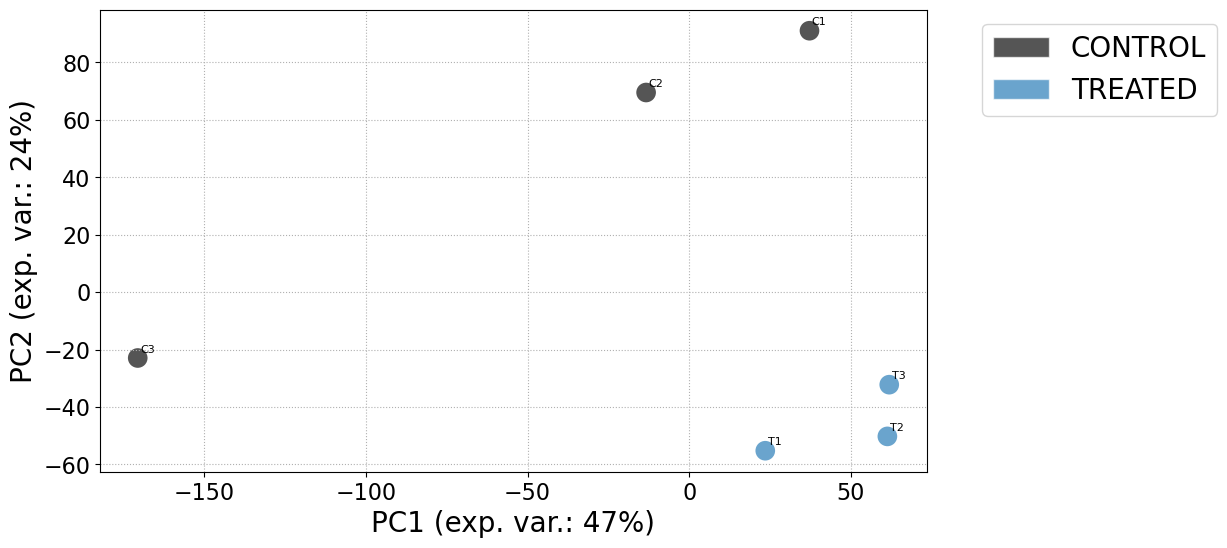

In [10]:
for i in range(len(new)):

    name = expression.columns[i]

    # colors
    if 'C' in name:
        the_color = 'black'
    elif 'T' in name:
        the_color = 'tab:blue'
    else:
        print('error')
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=200, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon=3
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')


legend_elements = [
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='black',      edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:blue',    edgecolor='white', alpha=2/3)
]

matplotlib.pyplot.legend(legend_elements, ['CONTROL', 'TREATED'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

# 4. visualize high expression

In [11]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.5226729  0.27674477]


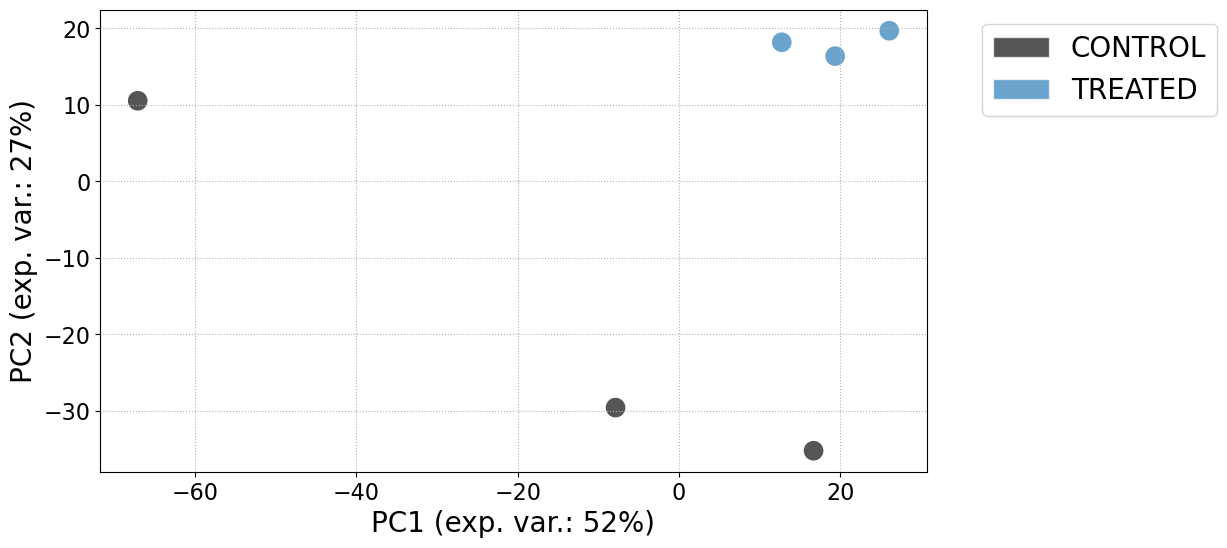

In [12]:
for i in range(len(new)):

    name = expression.columns[i]


    # colors
    if 'C' in name:
        the_color = 'black'
    elif 'T' in name:
        the_color = 'tab:blue'
    else:
        print('error')
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=200, c=the_color, marker='o', alpha=2/3, edgecolors='none')

legend_elements = [
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='black',      edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:blue',    edgecolor='white', alpha=2/3)
]    
matplotlib.pyplot.legend(legend_elements, ['CONTROL', 'TREATED'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))


matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

In [13]:
# 5. distributions

In [14]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,C1,C2,C3,T1,T2,T3
ENSG00000000003.15,4.512193,4.321256,4.028996,4.242234,3.955586,3.831068
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,7.315117,7.441267,7.694493,7.287445,7.217401,7.282676
ENSG00000000457.14,3.298496,3.185986,2.980503,3.170542,3.120662,3.176882
ENSG00000000460.17,4.857460,4.905256,4.751593,4.185983,4.296898,4.495958


145
14.216357221480623


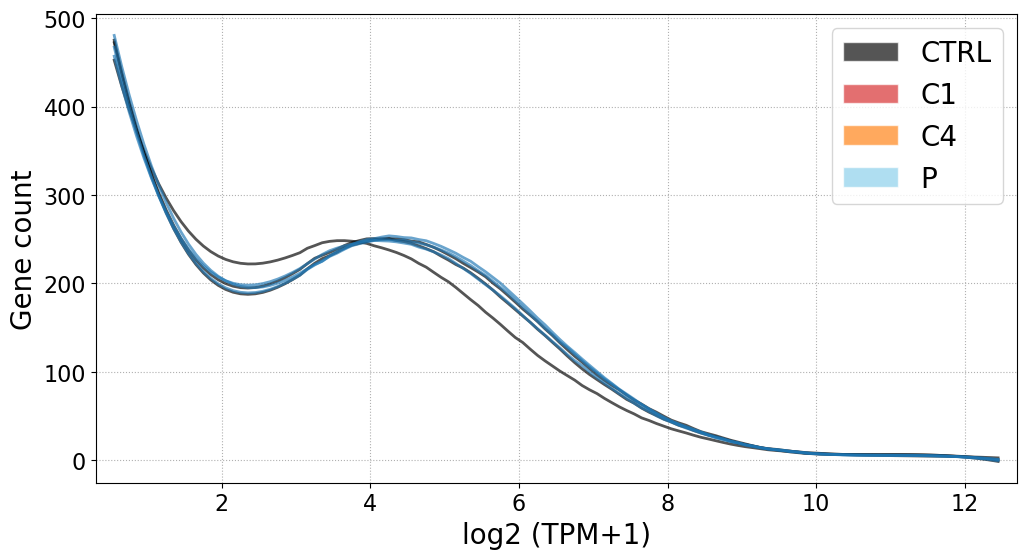

In [15]:
found_max = 14.5
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    name = working_samples[i]

    # colors
    if 'C' in name:
        the_color = 'black'
    elif 'T' in name:
        the_color = 'tab:blue'
    else:
        print('error')

    
    log2TPM = log2_tpm_PO.loc[:, name]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    #matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=2/3, color=the_color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])

legend_elements = [
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='black',      edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:red',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:orange', edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='skyblue',    edgecolor='white', alpha=2/3),
]


matplotlib.pyplot.legend(legend_elements, ['CTRL', 'C1', 'C4', 'P'], ncol=1, loc='upper right')

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)